In [16]:
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit_ibm_runtime.fake_provider import FakeAlgiers
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [4]:
angles = {
    'A0' : 0,
    'A1' : np.pi/4,
    'B0' : np.pi/8,
    'B1' : -np.pi/8
}

In [5]:
def chsh_circuit(alice_m_angle,bob_m_angle):
    qc = QuantumCircuit(2,2)
    qc.h(0)
    qc.cx(0,1)
    qc.barrier()
    qc.ry(2*alice_m_angle,0) #2* is the mapping of physical world to bloch sphere   
    qc.ry(2*bob_m_angle,1)
    
    qc.measure([0,1],[0,1])
    return qc

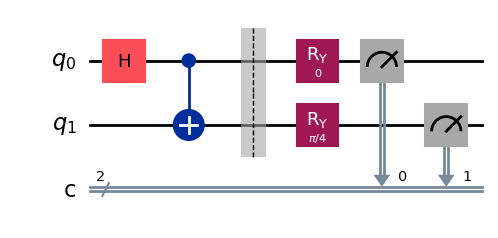

In [6]:
circuits = {
    'A0B0': chsh_circuit(angles['A0'],angles['B0']),
    'A0B1': chsh_circuit(angles['A0'],angles['B1']),
    'A1B0': chsh_circuit(angles['A1'],angles['B0']),
    'A1B1': chsh_circuit(angles['A1'],angles['B1']),
}

circuits['A0B0'].draw('mpl')

In [9]:
backend = FakeAlgiers()
pass_manager = generate_preset_pass_manager(optimization_level=1,backend=backend)
transpiled_ct = {name : pass_manager.run(qc) for name,qc in circuits.items()}

result = {}
for name,transpiled_ct in transpiled_ct.items():
    job = backend.run(transpiled_ct,shots = 8192) #2**13 = 8192 shots
    result[name] = job.result().get_counts()
    
print(result)

{'A0B0': {'00': 3484, '11': 3497, '01': 597, '10': 614}, 'A0B1': {'11': 3448, '10': 669, '00': 3465, '01': 610}, 'A1B0': {'00': 3502, '01': 662, '10': 641, '11': 3387}, 'A1B1': {'00': 648, '10': 3405, '01': 3464, '11': 675}}


In [14]:
chsh_data = []
expectation_values = {}

for name, counts in result.items():
    total_shots = sum(counts.values())
    c00 = counts.get('00',0)
    c01 = counts.get('01',0)
    c10 = counts.get('10',0)
    c11 = counts.get('11',0)
    
    p00 = c00 / total_shots
    p01 = c01 / total_shots
    p10 = c10 / total_shots
    p11 = c11 / total_shots
    
    E = p00 + p11 - p01 - p10 
    expectation_values[name] = E
    
    chsh_data.append({
        "Setup": name,
        "P(00)": f"{p00:.3f}",
        "P(01)": f"{p01:.3f}",
        "P(10)": f"{p10:.3f}",
        "P(11)": f"{p11:.3f}",
        "Expectation(E)": f"{E:.4f}"
        
    })  
    
df = pd.DataFrame(chsh_data)
print(df.to_string(index=False))

Setup P(00) P(01) P(10) P(11) Expectation(E)
 A0B0 0.425 0.073 0.075 0.427         0.7043
 A0B1 0.423 0.074 0.082 0.421         0.6877
 A1B0 0.427 0.081 0.078 0.413         0.6819
 A1B1 0.079 0.423 0.416 0.082        -0.6770


In [15]:
S = (
    expectation_values['A0B0'] +
    expectation_values['A0B1'] + 
    expectation_values['A1B0'] - 
    expectation_values['A1B1']
)

print("\n====================================")
print(f"Final CHSH Inequality Witness (S): {S:.4f}")
print("====================================")
print("Classical Bound:   |S| <= 2.0")
print("Ideal Quantum Bound:    ~ 2.828")

if abs(S) > 2.0:
    print("Result: Local Realism Violated! Quantum entanglement verified on mock hardware.")
else:
    print("Result: No violation. Hardware noise was too high to sustain entanglement.")


Final CHSH Inequality Witness (S): 2.7510
Classical Bound:   |S| <= 2.0
Ideal Quantum Bound:    ~ 2.828
Result: Local Realism Violated! Quantum entanglement verified on mock hardware.
